In [15]:
import pandas as pd

df = pd.read_csv("./scaled_df_2023.csv")

In [17]:
print(df.shape)

(25, 27)


In [19]:
print(df)

    평균_지진옥외대피소_밀도  평균_자전거편의시설_밀도  평균_택시승차대_밀도  평균_작은도서관_밀도  평균_에코스쿨위치_밀도  \
0        0.547105       0.847404     0.045586    -1.473170     -0.139130   
1       -0.808405       1.880422    -0.668297     0.791987     -0.260421   
2       -0.953786      -0.602316    -0.516304    -0.604573     -0.614229   
3        0.508313      -1.011901    -0.761546    -0.634175     -0.832547   
4       -0.529504      -1.134715    -0.825090     0.575353     -0.552907   
5       -0.859607       3.284968    -0.016070    -0.398373      0.044555   
6       -0.158115      -0.840854    -0.362809     2.126270     -0.208041   
7        0.146271      -1.060456     0.133562    -0.718642     -0.823592   
8       -0.677198       0.189705    -0.458956    -0.876304      0.203015   
9       -0.084521      -0.978918    -0.743180    -0.195428     -0.040556   
10       1.205703       0.800740    -0.564796     0.903978      3.686478   
11       0.482991      -0.625905    -0.377201     0.987592     -0.016370   
12      -0.0

In [21]:
df.head(3)

,평균_지진옥외대피소_밀도,평균_자전거편의시설_밀도,평균_택시승차대_밀도,평균_작은도서관_밀도,평균_에코스쿨위치_밀도,평균_한파쉼터_밀도,평균_보행등_밀도,평균_CCTV_밀도,평균_불법주정차CCTV_밀도,평균_나눔카_밀도,...,cctv,안내표지판,노면표기,보안등,서비스안내판,위치신고안내판,기타시설물,범죄발생정도,Grid개수,범죄발생정도평균
0,0.547105,0.847404,0.045586,-1.473170,-0.139130,-0.630199,-0.659940,0.508896,0.879787,0.522481,...,0.173342,-0.494228,-0.677263,0.114016,-0.222950,-0.114310,-0.198591,6763.0,78.0,86.705128
1,-0.808405,1.880422,-0.668297,0.791987,-0.260421,0.493574,0.620399,-0.230978,-0.850916,1.274388,...,-0.833541,-0.672808,0.107947,0.030266,-0.222950,-0.229787,-0.609597,3398.0,50.0,67.960000
2,-0.953786,-0.602316,-0.516304,-0.604573,-0.614229,0.236263,-1.149218,-0.789743,-0.303606,-1.347587,...,1.635693,2.345199,3.048038,1.490588,-0.141493,3.245619,0.577755,2497.0,45.0,55.488889


<Axes: >

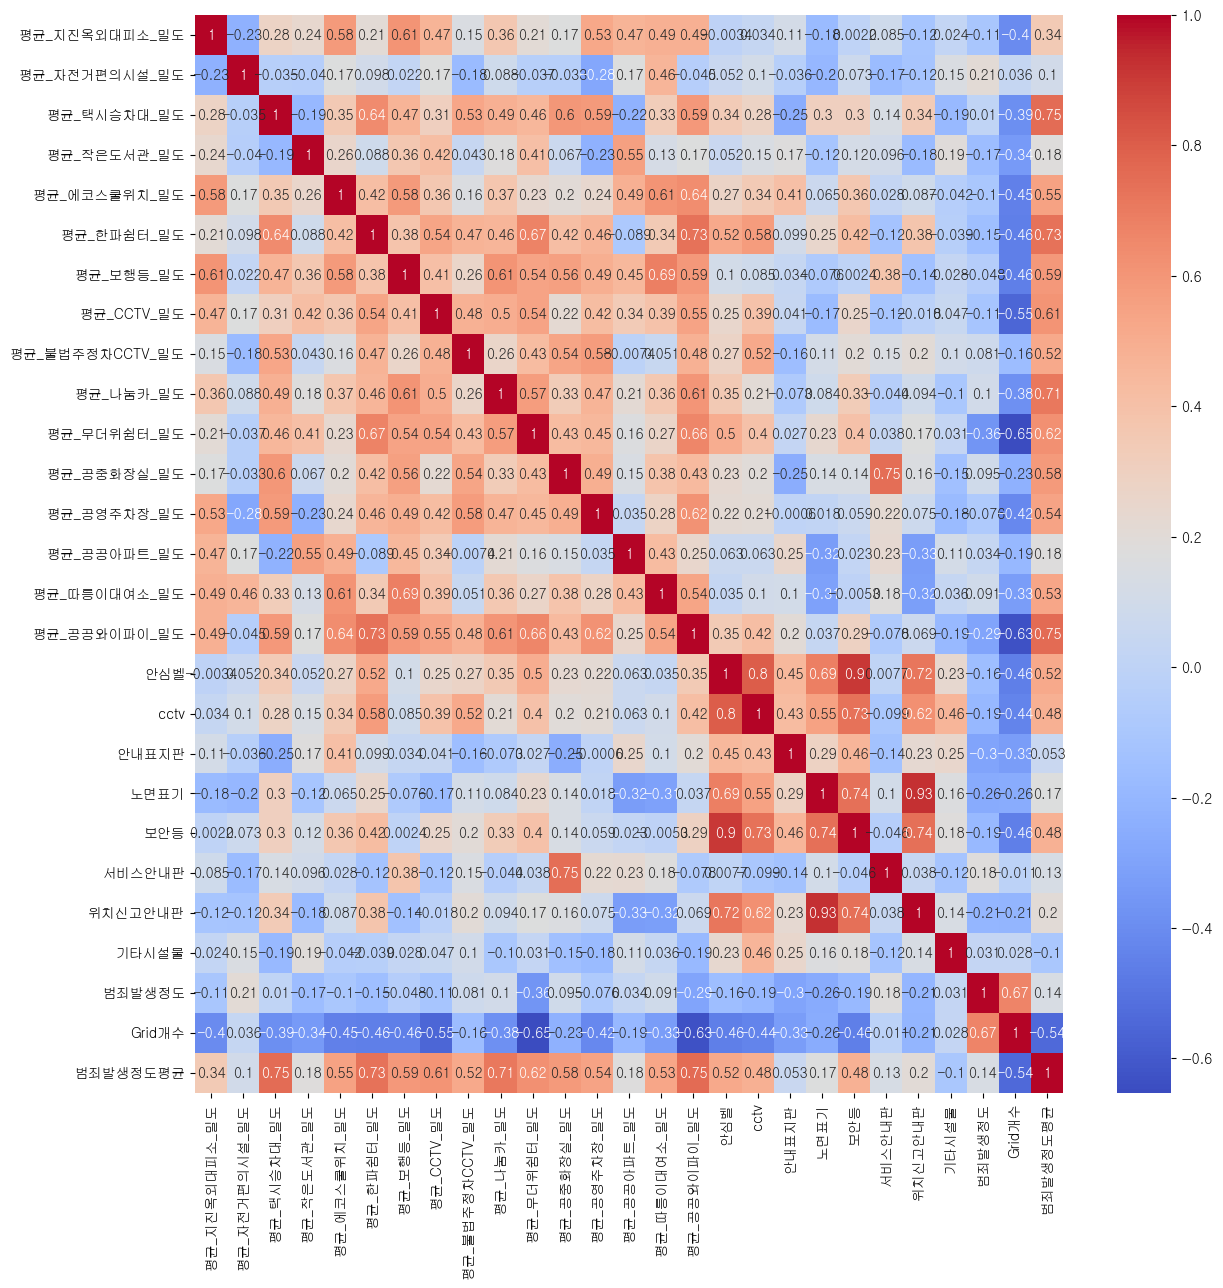

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

font_path = 'c:/WINDOWS/Fonts/GULIM.ttc'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

corr = df.corr()
plt.figure(figsize=(14,14))
sns.heatmap(corr, annot=True,cmap='coolwarm')

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols_mean1 = ['평균_공공와이파이_밀도','평균_한파쉼터_밀도','평균_무더위쉼터_밀도']

scaler = StandardScaler()
df_cols_scaled1 = scaler.fit_transform(df[cols_mean1])
pca1 = PCA(n_components=1)
pca1.fit(df_cols_scaled1)
print('PCA 컴포넘트 별 변동성', pca1.explained_variance_ratio_)

PCA 컴포넘트 별 변동성 [0.79283719]


In [27]:
cols_mean2 = ['평균_따릉이대여소_밀도','평균_보행등_밀도']

df_cols_scaled2 = scaler.fit_transform(df[cols_mean2])
pca2 = PCA(n_components=1)
pca2.fit(df_cols_scaled2)
print('PCA 컴포넘트 별 변동성', pca2.explained_variance_ratio_)

PCA 컴포넘트 별 변동성 [0.84342083]


In [29]:
cols_mean3 = ['평균_공영주차장_밀도','평균_불법주정차CCTV_밀도']

df_cols_scaled3 = scaler.fit_transform(df[cols_mean3])
pca3 = PCA(n_components=1)
pca3.fit(df_cols_scaled3)
print('PCA 컴포넘트 별 변동성', pca3.explained_variance_ratio_)

PCA 컴포넘트 별 변동성 [0.78826298]


In [33]:
cols_mean4 = ['평균_CCTV_밀도','노면표기', '보안등','위치신고안내판']

df_cols_scaled4 = scaler.fit_transform(df[cols_mean4])
pca4 = PCA(n_components=1)
pca4.fit(df_cols_scaled4)
print('PCA 컴포넘트 별 변동성', pca3.explained_variance_ratio_)

PCA 컴포넘트 별 변동성 [0.78826298]


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

pca1_component = pca1.fit_transform(df_cols_scaled1)
pca2_component = pca1.fit_transform(df_cols_scaled2)
pca3_component = pca1.fit_transform(df_cols_scaled3)
pca4_component = pca1.fit_transform(df_cols_scaled4)

df['와이+무더위+한파'] = pca1_component
df['따릉이+보행등'] = pca2_component
df['공주_불주'] = pca3_component
df['안심시설물+CCTV'] = pca4_component

# 회귀 분석
X = df[['안심시설물+CCTV','와이+무더위+한파', '따릉이+보행등', '공주_불주','평균_지진옥외대피소_밀도','평균_자전거편의시설_밀도','평균_택시승차대_밀도','평균_작은도서관_밀도','평균_에코스쿨위치_밀도','평균_CCTV_밀도','평균_나눔카_밀도','평균_공중화장실_밀도','평균_공공아파트_밀도']]
y = df['범죄발생정도평균']

# sklearn을 이용한 회귀 분석
model = LinearRegression()
model.fit(X, y)

# 예측 결과
y_pred = model.predict(X)

# 평가 지표 계산
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f'R^2: {r2}')
print(f'MSE: {mse}')
print(f'MAE: {mae}')

# statsmodels를 이용한 t-검정 유의수준 계산
X_with_const = sm.add_constant(X)  # 상수항 추가
sm_model = sm.OLS(y, X_with_const).fit()
print(sm_model.summary())

R^2: 0.8739646419507263
MSE: 100.20252913687034
MAE: 7.719218749936164
                            OLS Regression Results                            
Dep. Variable:               범죄발생정도평균   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     5.867
Date:                Thu, 13 Feb 2025   Prob (F-statistic):            0.00294
Time:                        18:55:06   Log-Likelihood:                -93.063
No. Observations:                  25   AIC:                             214.1
Df Residuals:                      11   BIC:                             231.2
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------